# Preambolo

In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import math
import sys
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
!pip install uncertainties
from uncertainties import ufloat
from uncertainties import unumpy as unp
from uncertainties.umath import sqrt
from uncertainties import ufloat
from scipy.constants import epsilon_0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00


In [ ]:
import os
import sys
import shutil

%cd /content/
if os.path.exists('/content/Esperienze-in-laboratorio'):
    shutil.rmtree('/content/Esperienze-in-laboratorio')

!git clone https://github.com/matteodeclich/Esperienze-in-laboratorio.git

percorso_libreria = '/content/Esperienze-in-laboratorio/Libreria_python'
if percorso_libreria not in sys.path:
    sys.path.insert(0, percorso_libreria)

try:
    from analisi_dati import *
    print("✅ Tutto pronto! Librerie installate e modulo importato.")
except Exception as e:
    print(f"❌ Errore durante l'import: {e}")

%cd Esperienze-in-laboratorio
%cd Coulomb

/content
Cloning into 'Esperienze-in-laboratorio'...
remote: Enumerating objects: 1554, done.
remote: Counting objects: 100% (461/461), done.
remote: Compressing objects: 100% (295/295), done.
remote: Total 1554 (delta 226), reused 388 (delta 157), pack-reused 1093 (from 1)
Receiving objects: 100% (1554/1554), 21.34 MiB | 20.97 MiB/s, done.
Resolving deltas: 100% (796/796), done.
✅ Tutto pronto! Librerie installate e modulo importato.
/content/Esperienze-in-laboratorio
/content/Esperienze-in-laboratorio/Coulomb


In [ ]:
!git pull

Already up to date.


# Dipendenza dalla distanza


In [ ]:
percorso_file = '/content/Esperienze-in-laboratorio/Coulomb/Coulomb.xlsx'
df = pd.read_excel(percorso_file, sheet_name=0)
df = df.fillna('')
df

,Unnamed: 0,r [m],Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,d [m]
0,,0.06,0.08,0.1,0.15,0.18,0.039
1,θ [°],97.0,70.0,49.0,28.0,20.0,σd [m]
2,,101.0,68.0,51.0,28.0,18.0,0.001
3,,99.0,71.0,53.0,31.0,22.0,
4,,,,,,,
5,M [°],99.0,69.666667,51.0,29.0,20.0,
6,M [rad],1.727876,1.215913,0.890118,0.506145,0.349066,
7,σ [°],2.0,1.527525,2.0,1.732051,2.0,
8,σ [rad],0.034907,0.02666,0.034907,0.03023,0.034907,
9,σM [°],1.154701,0.881917,1.154701,1.0,1.154701,


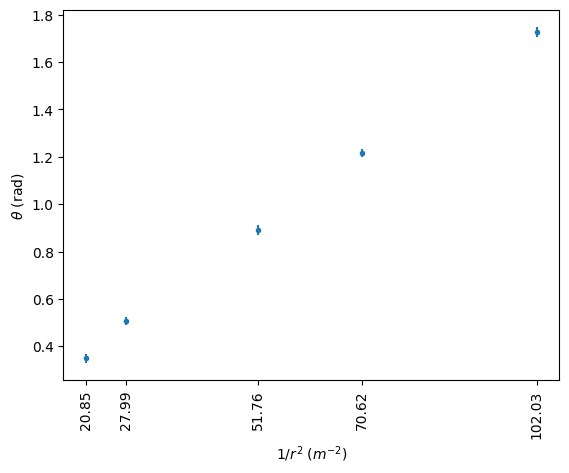

In [ ]:
d_th0 = pd.to_numeric(df.iloc[6, 1:6], errors='coerce').dropna().values
d_sth0 = pd.to_numeric(df.iloc[10, 1:6], errors='coerce').dropna().values
th0 = unp.uarray(d_th0, d_sth0)

d_r0 = pd.to_numeric(df.iloc[12, 1:6], errors='coerce').dropna().values
d_sr0 = np.full(len(d_r0), 0.001)
r0 = unp.uarray(d_r0, d_sr0)

d_a = pd.to_numeric(df.iloc[0, 6], errors='coerce')/2
a = ufloat(d_a, 0.001)

B0 = 1-((4*a**3)/r0**3)

th0_c = th0/B0

x=1/r0**2
plt.errorbar(unp.nominal_values(x), unp.nominal_values(th0), yerr=unp.std_devs(th0), fmt='o', ls='none', label='Dati', ms=3)
plt.xticks(unp.nominal_values(x))
plt.xticks(rotation=90)
plt.xlabel(r'$1/r^2$ ($m^{-2}$)')
plt.ylabel(r'$\theta$ (rad)')
plt.show()

Il risultato del fit y = k0·x è:
  k0 = 0.017502171±0.000141683


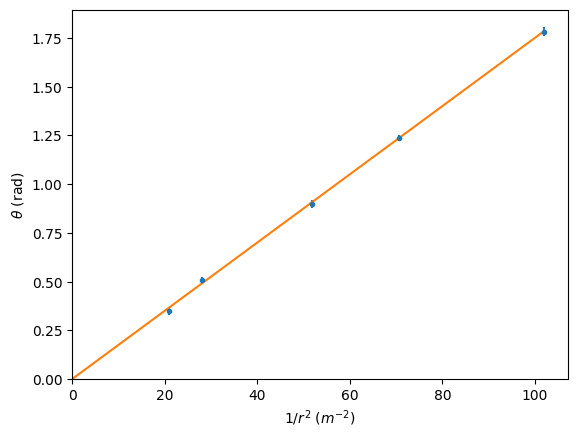

Il risultato del test del χ² è:
  χ²               = 1.7590785
  Gradi di libertà = 4
  χ² ridotto       = 0.43976963
  Il p-value associato è: 0.77996005


In [ ]:
k0 = minquadw_kx(unp.nominal_values(x), unp.nominal_values(th0_c), unp.std_devs(th0_c), "k0" )

def retta(x, k0):
    return x * k0
t = np.linspace(0, max(unp.nominal_values(x)), 100)


plt.errorbar(unp.nominal_values(x), unp.nominal_values(th0_c), yerr=unp.std_devs(th0_c), fmt='o', ls='none', label='none', ms=3)
plt.plot(t, retta(t, k0.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$1/r^2$ ($m^{-2}$)')
plt.ylabel(r'$\theta$ (rad)')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(th0_c), x*k0, unp.std_devs(th0_c), 1);
print("="*70)

# Carica: Stesso Potenziale


In [ ]:
df1=pd.read_excel(percorso_file, sheet_name=1)
df1=df1.fillna('')
df1

,V [V],σV [V],θ [°],θ [rad],σθ [rad],Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,6000,60,70,1.221730,0.069813,,,,,,,,,...
1,5500,60,62,1.082104,0.069813,,,,,,,,,
2,5000,60,48,0.837758,0.069813,,,,,,,,,
3,4500,60,41,0.715585,0.069813,,,,,,,,,
4,4000,60,35,0.610865,0.069813,,,,,,,,,
5,3500,60,23,0.401426,0.069813,,,,,,,,,
6,3000,60,20,0.349066,0.069813,,,,,,,,,
7,2500,60,14,0.244346,0.069813,,,,,,,,,
8,2000,60,10,0.174533,0.069813,,,,,,,,,


Il risultato del fit y = k1·x è:
  k1 = (3.5509617±0.1154959)×10⁻⁸


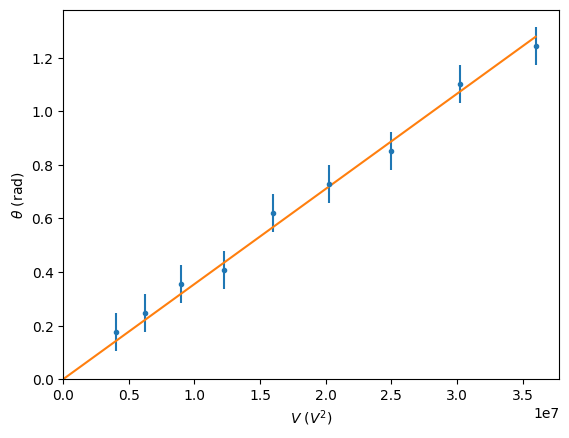

Il risultato del test del χ² è:
  χ²               = 1.9984492
  Gradi di libertà = 8
  χ² ridotto       = 0.24980615
  Il p-value associato è: 0.98105935


In [ ]:
d_th1 = pd.to_numeric(df1.iloc[0:9, 3], errors='coerce').values
d_sth1 = pd.to_numeric(df1.iloc[0:9, 4], errors='coerce').values
th1 = unp.uarray(d_th1, d_sth1)

d_r1 = 0.12
d_sr1 = 0.001
r1 = ufloat(d_r1, d_sr1)

d_V0 = pd.to_numeric(df1.iloc[0:9, 0], errors='coerce').values
d_sV0 = pd.to_numeric(df1.iloc[0:9, 1], errors='coerce').values
V0 = unp.uarray(d_V0, d_sV0)

B1 = 1-((4*a**3)/r1**3)

th1_c = th1/B1

x1 = V0**2

k1 = minquadw_kx(unp.nominal_values(x1), unp.nominal_values(th1_c), unp.std_devs(th1_c), "k1" )

t = np.linspace(0, np.max(unp.nominal_values(x1)), 100)

plt.errorbar(unp.nominal_values(x1), unp.nominal_values(th1_c), yerr=unp.std_devs(th1_c), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k1.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$V$ ($V^2$)')
plt.ylabel(r'$\theta$ (rad)')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(th1_c), x1*k1, unp.std_devs(th1_c), 1);
print("="*70)

# Carica: Potenziale Diverso

In [ ]:
df2=pd.read_excel(percorso_file, sheet_name=2)
df2=df2.fillna('')
df2


,V [V],σV [V],θ [°],θ [rad],σθ [rad],V fisso
0,6000,60,70,1.221730,0.069813,6000.0
1,5500,60,65,1.134464,0.069813,
2,5000,60,61,1.064651,0.069813,
3,4500,60,59,1.029744,0.069813,
4,4000,60,52,0.907571,0.069813,
5,3500,60,43,0.750492,0.069813,
6,3000,60,39,0.680678,0.069813,
7,2500,60,35,0.610865,0.069813,
8,2000,60,28,0.488692,0.069813,


Il risultato del fit y = k2·x è:
  k2 = 0.00021969214±0.00000563781


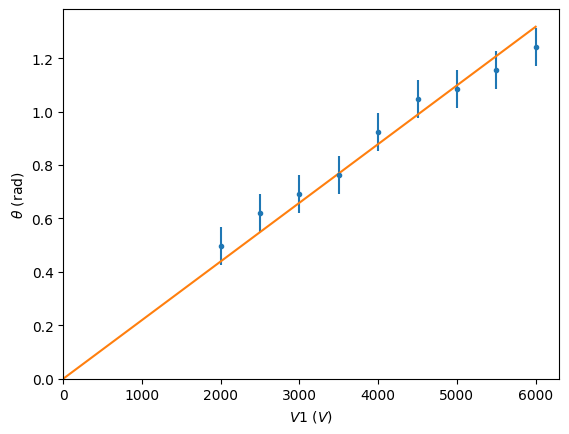

Il risultato del test del χ² è:
  χ²               = 4.7503468
  Gradi di libertà = 8
  χ² ridotto       = 0.59379336
  Il p-value associato è: 0.78389567


In [ ]:
d_th2 = pd.to_numeric(df2.iloc[0:9, 3], errors='coerce').values
d_sth2 = pd.to_numeric(df2.iloc[0:9, 4], errors='coerce').values
th2 = unp.uarray(d_th2, d_sth2)

d_r2 = 0.12
d_sr2 = 0.001
r2 = ufloat(d_r2, d_sr2)

d_V1 = pd.to_numeric(df2.iloc[0:9, 0], errors='coerce').values
d_sV1 = pd.to_numeric(df2.iloc[0:9, 1], errors='coerce').values
V1 = unp.uarray(d_V1, d_sV1)

V2 = ufloat(6000, 60)

B2 = 1-((4*a**3)/r2**3)

th2_c = th2/B2

x2 = V1

k2 = minquadw_kx(unp.nominal_values(x2), unp.nominal_values(th2_c), unp.std_devs(th2_c), "k2")

t = np.linspace(0, np.max(unp.nominal_values(x2)), 100)

plt.errorbar(unp.nominal_values(x2), unp.nominal_values(th2_c), yerr=unp.std_devs(th2_c), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k2.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel(r'$V1$ ($V$)')
plt.ylabel(r'$\theta$ (rad)')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(th2_c), x2*k2, unp.std_devs(th2_c), 1);
print("="*70)

# Costante di Torsione


In [ ]:
df3=pd.read_excel(percorso_file, sheet_name=3)
df3=df3.fillna('')
df3

,m [kg],θ [°],θ [rad],σθ [rad]
0,0.00002,136,2.373648,0.069813
1,0.00004,282,4.921828,0.069813
2,0.00005,355,6.195919,0.069813
3,0.00007,500,8.726646,0.069813
4,0.00009,645,11.257374,0.069813


Il risultato del fit y = k3·x è:
  k3 = 0.12446691±0.00052774


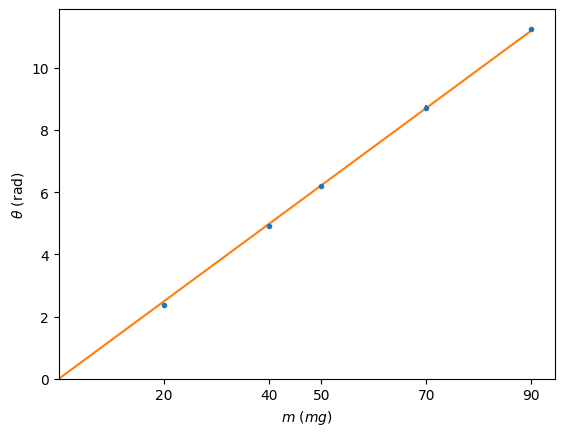

Il risultato del test del χ² è:
  χ²               = 4.2321429
  Gradi di libertà = 4
  χ² ridotto       = 1.0580357
  Il p-value associato è: 0.37549941
Il valore di K_tor è: (7.879±0.033)×10⁻⁵


In [ ]:
d_th3 = pd.to_numeric(df3.iloc[0:5, 2], errors='coerce').values
d_sth3 = pd.to_numeric(df3.iloc[0:5, 3], errors='coerce').values
th3 = unp.uarray(d_th3, d_sth3)

M = pd.to_numeric(df3.iloc[0:5, 0]*10**6, errors='coerce').values

x3 = M

k3 = minquadw_kx(unp.nominal_values(x3), unp.nominal_values(th3), unp.std_devs(th3), "k3" )

t = np.linspace(0, np.max(unp.nominal_values(x3)), 100)

plt.errorbar(unp.nominal_values(x3), unp.nominal_values(th3), yerr=unp.std_devs(th3), fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k3.nominal_value))

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xticks(unp.nominal_values(M))
plt.xlabel(r'$m$ ($mg$)')
plt.ylabel(r'$\theta$ (rad)')
plt.show()

print("="*70)
chi_quadro(unp.nominal_values(th3), x3*k3, unp.std_devs(th3), 1);
print("="*70)
K_tor=g/(k3*10**(6))
print(f"Il valore di K_tor è: {K_tor:.4P}")
print("="*70)

# Test di Compatibilità

In [ ]:
epsilon0 = (K_tor*k0)/(4*np.pi*(V2**2)*(a**2))
epsilon1 = (K_tor*k1*(r1**2))/(4*np.pi*(a**2))
epsilon2 = (K_tor*k2*(r1**2))/(4*np.pi*V2*(a**2))

epsilon_best = ((unp.nominal_values(epsilon0)/unp.std_devs(epsilon0)**2)+(unp.nominal_values(epsilon1)/unp.std_devs(epsilon1)**2)+(unp.nominal_values(epsilon2)/unp.std_devs(epsilon2)**2))/((1/unp.std_devs(epsilon0)**2)+(1/unp.std_devs(epsilon1)**2)+(1/unp.std_devs(epsilon2)**2))
sigma_best = 1/unp.sqrt(((1/unp.std_devs(epsilon0)**2)+(1/unp.std_devs(epsilon1)**2)+(1/unp.std_devs(epsilon2)**2)))
e0 = ufloat(epsilon_best, sigma_best)

print("="*70)
print(f"Il valore di epsilon0 è: {epsilon0:.4P}")
print(f"Il valore di epsilon1 è: {epsilon1:.4P}")
print(f"Il valore di epsilon2 è: {epsilon2:.4P}")
print("="*70)
print(f"Il di epsilon_best è: {e0:.4P}")
eps=8.85*10**(-12)
compatibilita_valore(e0, eps);
print("="*70)

Il valore di epsilon0 è: (8.016±0.841)×10⁻¹²
Il valore di epsilon1 è: (8.431±0.919)×10⁻¹²
Il valore di epsilon2 è: (8.694±0.935)×10⁻¹²
Il di epsilon_best è: (8.355±0.517)×10⁻¹²
Compatibilità di misura con 8.85e-12: |t| = 0.95814749
